# Course Project: Fantasy Premier League Dataset 2025-26
![image info](./images/dataset-cover.png)

## Introduction
As an avid Fantasy Premier League player, I decided to devote this project to exploring player fantasy data from the current Premier League season of 2025-26. My hope is to glean some meaningful insights of players to either target or drop from my roster. Ideally, this project would highlight players that outperform/underperform their price in the fantasy league.

### Goal of the Project
- Calculate my own metric for player performance within the fantasy football scoring system, i.e., show which players are most valuable for scoring fantasy points based on the data.
- Construct a predictive model to assess future performance based on underlying metrics
- Pinpoint players worth targetting in the remaining fixtures of the fantasy season
- Learn a bit more about data analysis along the way

### Dataset description
The publically available dataset is available through Kaggle at [https://www.kaggle.com/datasets/meraxes10/fantasy-premier-league-dataset-2025-2026/data](https://www.kaggle.com/datasets/meraxes10/fantasy-premier-league-dataset-2025-2026/data). The latest dataset was retrieved on Sunday, May 10th, 2026 and is provided in Github repository under project/data/ as a CSV-file. The dataset includes data from 834 players (rows) expressed with 92 variables (columns). 

### Statement of AI use
AI is not used for assistance when constructing the project itself. Re-using code from previous assignments and exercises, where AI has assisted in formulating code for visualizations or quantitative analysis.

## Instructions
Run the code blocks in the order they appear to avoid potential issues. To successfully replicate the output, please download the /data -folder holding the dataset used in this project. 

Please ensure that you have a valid Gemini API-key. Google's Gemini API can be obtained from [Google AI Studio](https://aistudio.google.com/apikey) and was used during Exercise 3. Your API-key has to be included in a .env-file located in the same directory as this notebook. The API-key is expected to be named "GEMINI_API_KEY". 

### Requisites:
- The dataset "players.csv" -file is included in the Github repository under project/data/
- The LLM classification requires an API-key to access Gemini online
 

## Loading the player data
In this section, we will ingest the dataset as a Pandas DataFrame

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/players.csv")
df.head()

,id,name,now_cost,position,team,transfers_out_event,team_join_date,form_rank,recoveries,creativity_rank_type,...,can_select,cost_change_start_fall,saves,ict_index,expected_goals_conceded_per_90,bonus,in_dreamteam,expected_goal_involvements,creativity,goals_conceded_per_90
0,1,David Raya Martín,61,GKP,Arsenal,2651,2024-07-04,34,298,3,...,True,-6,59,55.0,0.75,9,True,0.06,33.5,0.73
1,2,Kepa Arrizabalaga Revuelta,40,GKP,Arsenal,34,2025-07-01,470,0,54,...,True,5,0,0.0,0.00,0,False,0.00,0.0,0.00
2,3,Karl Hein,40,GKP,Arsenal,10,2020-10-28,489,0,64,...,False,0,0,0.0,0.00,0,False,0.00,0.0,0.00
3,4,Tommy Setford,39,GKP,Arsenal,33,2024-07-24,456,0,45,...,True,1,0,0.0,0.00,0,False,0.00,0.0,0.00
4,5,Gabriel dos Santos Magalhães,73,DEF,Arsenal,1754,2020-09-01,36,61,75,...,True,-13,0,118.0,0.70,27,True,4.56,125.8,0.66


## Exploratory data analysis
In this section, we will perform a short exploratory data analysis on the dataset.

In [2]:
# Checking summary statistics
print("Dataset Shape:", df.shape)
display(df.info())
display(df.describe())
# The dataset includes data of 834 players (rows), presented with 92 variables (columns)

Dataset Shape: (834, 92)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 834 entries, 0 to 833
Data columns (total 92 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    834 non-null    int64  
 1   name                                  834 non-null    object 
 2   now_cost                              834 non-null    int64  
 3   position                              834 non-null    object 
 4   team                                  834 non-null    object 
 5   transfers_out_event                   834 non-null    int64  
 6   team_join_date                        814 non-null    object 
 7   form_rank                             834 non-null    int64  
 8   recoveries                            834 non-null    int64  
 9   creativity_rank_type                  834 non-null    int64  
 10  selected_rank                         834 non-null    int64  

None

,id,now_cost,transfers_out_event,form_rank,recoveries,creativity_rank_type,selected_rank,clearances_blocks_interceptions,threat_rank,total_points,...,now_cost_rank_type,penalties_order,cost_change_start_fall,saves,ict_index,expected_goals_conceded_per_90,bonus,expected_goal_involvements,creativity,goals_conceded_per_90
count,834.000000,834.000000,834.000000,834.000000,834.000000,834.000000,834.000000,834.000000,834.000000,834.000000,...,834.000000,59.000000,834.00000,834.000000,834.000000,834.000000,834.000000,834.000000,834.000000,834.000000
mean,417.500000,48.767386,701.594724,417.500000,40.169065,139.015588,417.500000,33.396882,417.500000,38.899281,...,139.015588,2.508475,1.12470,2.376499,42.229496,1.126127,2.693046,1.961343,123.380695,1.154233
std,240.899357,10.681062,2887.314970,240.899357,56.427637,101.827071,240.899357,55.434480,240.899357,47.854014,...,101.827071,1.194425,2.00091,13.649346,55.778412,1.924544,4.861518,3.331276,198.790846,3.506349
min,1.000000,37.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,-14.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,209.250000,43.000000,4.000000,209.250000,0.000000,53.000000,209.250000,0.000000,209.250000,0.000000,...,53.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,417.500000,45.000000,27.000000,417.500000,13.000000,114.000000,417.500000,7.000000,417.500000,14.000000,...,114.000000,2.000000,1.00000,0.000000,12.300000,1.240000,0.000000,0.180000,14.300000,1.100000
75%,625.750000,52.000000,227.500000,625.750000,65.000000,218.000000,625.750000,44.000000,625.750000,69.000000,...,218.000000,3.000000,2.00000,0.000000,73.775000,1.490000,4.000000,2.707500,177.275000,1.500000
max,834.000000,147.000000,43519.000000,834.000000,320.000000,375.000000,834.000000,343.000000,834.000000,230.000000,...,375.000000,5.000000,7.00000,127.000000,350.100000,32.400000,40.000000,27.420000,1780.200000,90.000000


#### Notes:
- Most variable include no non-null values
- Exceptions include variables such as free-kick and penalty takers

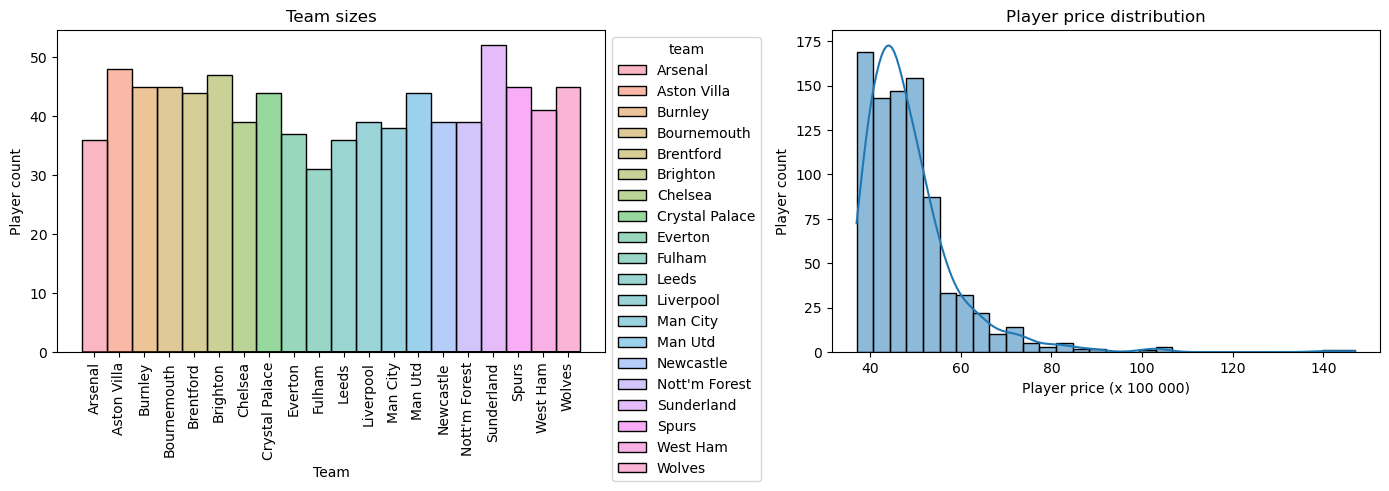

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

# Plot 1: 
plt.subplot(1, 2, 1)
ax = sns.histplot(x="team", hue ="team", data=df)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("Team sizes")
plt.ylabel("Player count")
plt.xlabel("Team")
plt.xticks(rotation=90)

# Plot 2: 
plt.subplot(1, 2, 2)
sns.histplot(data=df, x="now_cost", multiple="stack", bins=30, kde=True)
plt.title("Player price distribution")
plt.ylabel("Player count")
plt.xlabel("Player price (x 100 000)")

plt.tight_layout()
plt.show()

#### Note:
The player prices are given in units of 100 000 monetary units. i.e. ranging from current values of 3.7M to 14.7M. The number of players registered to each squad roster varies quite a bit.

## Cleaning and transforming the data
In progress

## Visual analysis
In progress

## Quantitative analysis
In progress

## LLM classification (Gemini)

### Loading the API-key

In [8]:
from dotenv import load_dotenv
import os

# Load all variables from .env into the environment
load_dotenv()

api_key = os.environ.get("GEMINI_API_KEY")

if api_key:
    print(f"Key loaded: {api_key[:5]}...")
else:
    print("ERROR: GEMINI_API_KEY not found. Check your .env file.")

Key loaded: AIzaS...


## Exports

In [9]:
# Creating a subfolder if none exist
os.makedirs('exports', exist_ok=True)

# Exporting as a CSV file for back-up
df.to_csv("exports/playerdata.csv", index=False)

print("DataFrame exported to exports/playerdata.csv")

DataFrame exported to exports/playerdata.csv


## Conclusion
Due to unfortunate scheduling issues, I was unable to complete the project beyond the introductory phase. Therefore, no conclusions can be drawn.